# Imports

In [1]:
import torch
from torch.utils.data import random_split, Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
from tqdm import tqdm
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import hashlib
from collections import defaultdict
import math

# Constants

In [2]:
device = 'cuda'

# Dataset

In [3]:
class CompoundDataset(Dataset):
    def __init__(self, X: torch.tensor, Y: torch.tensor):
        super().__init__()
        self.X = X
        self.Y = Y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.Y[index]

Load the data

In [4]:
dataset = torch.load('../compound/dataset.pt')

C:\Users\agile\AppData\Local\Temp\ipykernel_15868\3031862531.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset = torch.load('../compound/dataset.pt')


# Split

In [5]:
# constants
DATASET_SIZE = len(dataset)  # Should be 499
TRAIN_RATIO = 0.9
TEST_RATIO = 1 - TRAIN_RATIO

# lengths of splits
train_len = int(TRAIN_RATIO * DATASET_SIZE)
test_len = DATASET_SIZE - train_len

torch.manual_seed(196)
train_dataset, test_dataset = random_split(dataset, [train_len, test_len])

Discretize

In [6]:
# precisions = [0.01, 0.1, 0.1, 0.01, 0.01, 0.1, 0.01, 0.1]
precisions = [0.1, 0.1]
bin_widths = []
for col_idx in range(train_dataset.dataset.Y.shape[1]):
    column = train_dataset.dataset.Y[train_dataset.indices, col_idx]
    column, _ = torch.sort(column)
    diffs = torch.diff(column)
    medain_diff = torch.median(diffs)
    if torch.isclose(medain_diff, torch.tensor(0.0)):
        medain_diff = precisions[col_idx]
    bin_widths.append(medain_diff)

bin_widths = torch.tensor(bin_widths)
print(bin_widths)

tensor([1.2000, 1.6000])


C:\Users\agile\AppData\Local\Temp\ipykernel_15868\1188392513.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  bins = np.arange(column_numpy.min(), column_numpy.max() + bin_width, bin_width)


Number of bins: 391


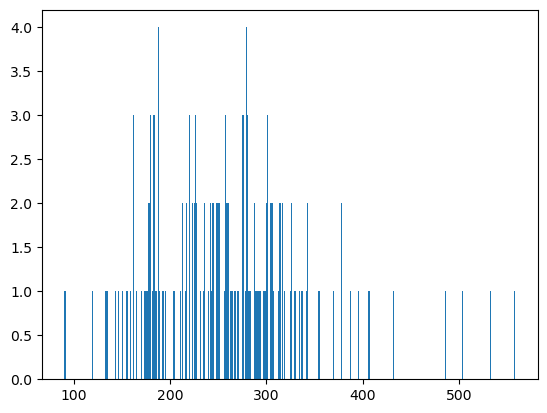

Number of bins: 317


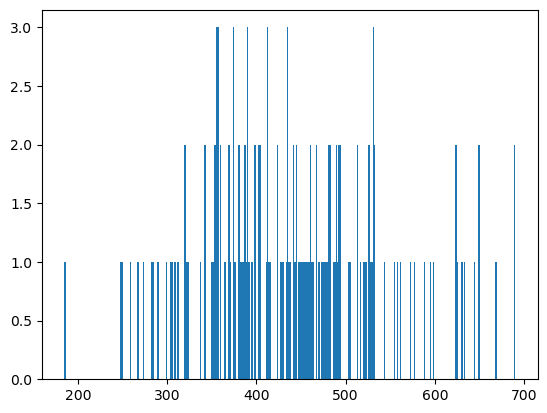

In [7]:
num_bins = []
for col_idx in range(train_dataset.dataset.Y.shape[1]):
    column = train_dataset.dataset.Y[:, col_idx]
    column_numpy = column.cpu().numpy()
    bin_width = bin_widths[col_idx]
    bins = np.arange(column_numpy.min(), column_numpy.max() + bin_width, bin_width)
    print(f'Number of bins: {len(bins)}')
    num_bins.append(len(bins))
    plt.hist(column_numpy, bins=bins)
    plt.show()

# Probabilistic Dataset

Calculate dependent probabilities over bins.

In [8]:
class ProbDataset(Dataset):
    def __init__(self, X: torch.tensor, Y: torch.tensor, bin_count, bin_width):
        super().__init__()
        self.X = X
        self.Y = Y
        self.bin_count = bin_count
        self.bin_width = bin_width
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.Y[index]

In [9]:
def get_tensor_to_probabilities(X: torch.tensor, Y: torch.tensor, num_bins: int, bin_width: float):
    tensor_to_probs = defaultdict(lambda: np.zeros(num_bins))
    Y_min = torch.min(Y).item()
    for row_idx in range(X.shape[0]):
        row_tens = X[row_idx]
        hash = hashlib.sha256(row_tens.detach().cpu().numpy().tobytes()).hexdigest()
        freq = tensor_to_probs[hash]
        
        val = Y[row_idx]
        bin_index = math.floor((val - Y_min) / bin_width)
        freq[bin_index] += 1
    
    for hash in tensor_to_probs:
        freqs = tensor_to_probs[hash]
        tensor_to_probs[hash] = freqs / freqs.sum()
    
    return tensor_to_probs

In [10]:
def create_y(X: torch.tensor, tensor_to_probs):
    Y = []
    for row_idx in range(X.shape[0]):
        row_tens = X[row_idx]
        hash = hashlib.sha256(row_tens.detach().cpu().numpy().tobytes()).hexdigest()
        Y.append(torch.from_numpy(tensor_to_probs[hash].astype(np.float32)))
    
    return torch.stack(Y)

In [11]:
y_names = ['melting_point_K', 'boiling_point_K']
def create_probabilistic_datasets(train_part, test_part, num_bins, bin_widths, y_names):
    num_names = len(y_names)
    X_train = train_part.dataset.X[train_part.indices]
    X_test = test_part.dataset.X[test_part.indices]
    
    for col_idx in range(num_names):
        train_ttf = get_tensor_to_probabilities(
            X_train,
            train_part.dataset.Y[train_part.indices, col_idx].flatten(),
            num_bins[col_idx],
            bin_widths[col_idx]
        )
        
        test_ttf = get_tensor_to_probabilities(
            X_test,
            test_part.dataset.Y[test_part.indices, col_idx].flatten(),
            num_bins[col_idx],
            bin_widths[col_idx]
        )
        
        Y_train = create_y(X_train, train_ttf)
        Y_test = create_y(X_test, test_ttf)
        
        final_train_dataset = ProbDataset(X_train, Y_train, num_bins[col_idx], bin_widths[col_idx])
        final_test_dataset = ProbDataset(X_test, Y_test, num_bins[col_idx], bin_widths[col_idx])
        
        print(f'Saving final train dataset:\n\tX.shape = {X_train.shape}\n\tY.shape = {Y_train.shape}\n')
        torch.save(final_train_dataset, f'{y_names[col_idx]}_train.pt')
        
        print(f'Saving final test dataset:\n\tX.shape = {X_test.shape}\n\tY.shape = {Y_test.shape}\n')
        torch.save(final_test_dataset, f'{y_names[col_idx]}_test.pt')

In [12]:
create_probabilistic_datasets(train_dataset, test_dataset, num_bins, bin_widths, y_names)

Saving final train dataset:
	X.shape = torch.Size([136, 6])
	Y.shape = torch.Size([136, 391])

Saving final test dataset:
	X.shape = torch.Size([16, 6])
	Y.shape = torch.Size([16, 391])

Saving final train dataset:
	X.shape = torch.Size([136, 6])
	Y.shape = torch.Size([136, 317])

Saving final test dataset:
	X.shape = torch.Size([16, 6])
	Y.shape = torch.Size([16, 317])

